# Paranal Tomographic Forecasting

This notebook demonstrates scalar seeing nowcasting on the ESO Paranal benchmark using two lightweight baselines that run on limited hardware:

1. **Persistence** — predicts the most recent observed value (zero-compute lower bound)
2. **GBRT** — a LightGBM gradient-boosted regression tree (fast tree-based upper bound)

**Task**: `forecasting.paranal_tomography.full.seeing_nowcast` — predicting scalar seeing 5 minutes ahead from a 20-minute observation window of surface meteorology and thermodynamic profiles.

**Hardware**: Both models train and evaluate in under 60 seconds on a 2-core laptop with 8 GB RAM.

In [1]:
import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from otbench import TaskApi
from otbench.benchmark.models.forecasting import (
    PersistenceForecastingModel,
    GradientBoostingForecastingModel,
)

pp = pprint.PrettyPrinter(indent=2, width=100, compact=True)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'serif'

## 1. Load the Task

The `seeing_nowcast` task defines:
- **Window**: 20 minutes of history (surface meteo + LHATPRO thermodynamics)
- **Horizon**: 5 minutes ahead
- **Target**: Scalar seeing in arcseconds (linear, not log-transformed)
- **Metrics**: RMSE and MAE

In [2]:
task_api = TaskApi()
task = task_api.get_task("forecasting.paranal_tomography.full.seeing_nowcast")

task_info = task.get_info()
pp.pprint(task_info)

{ 'description': 'Scalar Nowcasting (Operational)',
  'description_long': 'Predicting scalar seeing 5 minutes ahead to optimize queue scheduling. '
                      'Seeing is evaluated in linear arcseconds (log_transform=false) as the '
                      'distribution spread is narrow enough for RMSE to be meaningful without '
                      'transformation.',
  'dropna': False,
  'ds_name': 'paranal_tomography',
  'eval_metrics': ['root_mean_square_error', 'mean_absolute_error'],
  'forecast_horizon': 5,
  'log_transform': False,
  'obs_lat': -24.62,
  'obs_lon': -70.4,
  'obs_tz': 'Chile/Continental',
  'remove': [ 'time', 'cn2_free_atmos', 'cn2_ground_scalar', 'cn2_free_atmos_500',
              'cn2_free_atmos_1000', 'cn2_free_atmos_2000', 'cn2_free_atmos_4000',
              'cn2_free_atmos_8000', 'cn2_free_atmos_16000', 'seeing'],
  'session_col': 'night_id',
  'target': 'seeing',
  'test_idx': ['500000:620000'],
  'train_idx': ['0:400000'],
  'val_idx': ['400000

## 2. Prepare Training Data

The task API handles the train/val/test split. `prepare_forecasting_data` constructs the sliding-window feature matrix from the raw time series, respecting night boundaries via `session_col`.

In [3]:
X_train, y_train = task.get_train_data(data_type="pd")
X_val, y_val = task.get_validation_data(data_type="pd")

# Combine train + val for final model fitting (standard benchmark protocol)
X_combined = pd.concat([X_train, X_val])
y_combined = pd.concat([y_train, y_val])

# Construct sliding-window features
X_fw, y_fw = task.prepare_forecasting_data(X_combined, y_combined)
print(f"Training samples: {len(X_fw):,}")
print(f"Feature dimension: {X_fw.shape[1]}")
print(f"Target: {task.get_target_name()}")

Training samples: 131,459
Feature dimension: 860
Target: seeing


## 3. Baseline: Persistence Model

The persistence forecast assumes "seeing in 5 minutes ≈ seeing right now." This is the natural lower bound — any useful model must beat it.

In [4]:
persist = PersistenceForecastingModel(
    name="persistence",
    target_name=task.get_target_name(),
    window_size=task_info["window_size"],
    forecast_horizon=task_info["forecast_horizon"],
)
persist.train(X_fw, y_fw)

results_persist = task.evaluate_model(
    predict_call=persist.predict,
    detailed_metrics=True,
)
pp.pprint(results_persist)

{ 'mean_absolute_error': { 'detailed_score': [0.25755518868922894],
                           'metric_value': 0.25755518868922894,
                           'valid_predictions': 47247},
  'root_mean_square_error': { 'detailed_score': [0.3275319777300417],
                              'metric_value': 0.3275319777300417,
                              'valid_predictions': 47247}}


## 4. GBRT: Gradient-Boosted Regression Tree

A LightGBM model with conservative hyperparameters for limited hardware. LightGBM handles NaN features natively, which is important for this dataset (sparse union backbone with per-instrument tolerances).

In [5]:
gbrt = GradientBoostingForecastingModel(
    name="gbrt",
    target_name=task.get_target_name(),
    window_size=task_info["window_size"],
    forecast_horizon=task_info["forecast_horizon"],
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    num_leaves=31,
)
gbrt.train(X_fw, y_fw)

results_gbrt = task.evaluate_model(
    predict_call=gbrt.predict,
    detailed_metrics=True,
)
pp.pprint(results_gbrt)

{ 'mean_absolute_error': { 'detailed_score': [0.20536778368479172],
                           'metric_value': 0.20536778368479172,
                           'valid_predictions': 47247},
  'root_mean_square_error': { 'detailed_score': [0.26959025763605976],
                              'metric_value': 0.26959025763605976,
                              'valid_predictions': 47247}}


## 5. Comparison

Side-by-side evaluation and a visual comparison of prediction quality on a representative test segment.

In [6]:
# Summary table
metrics = ["root_mean_square_error", "mean_absolute_error"]
rows = []
for name, res in [("Persistence", results_persist), ("GBRT", results_gbrt)]:
    row = {"Model": name}
    for m in metrics:
        row[m] = res.get(m, {}).get("metric_value", float("nan"))
    rows.append(row)

df_results = pd.DataFrame(rows).set_index("Model")
df_results.columns = ["RMSE (arcsec)", "MAE (arcsec)"]
print(df_results.to_string(float_format="{:.4f}".format))

             RMSE (arcsec)  MAE (arcsec)
Model                                   
Persistence         0.3275        0.2576
GBRT                0.2696        0.2054


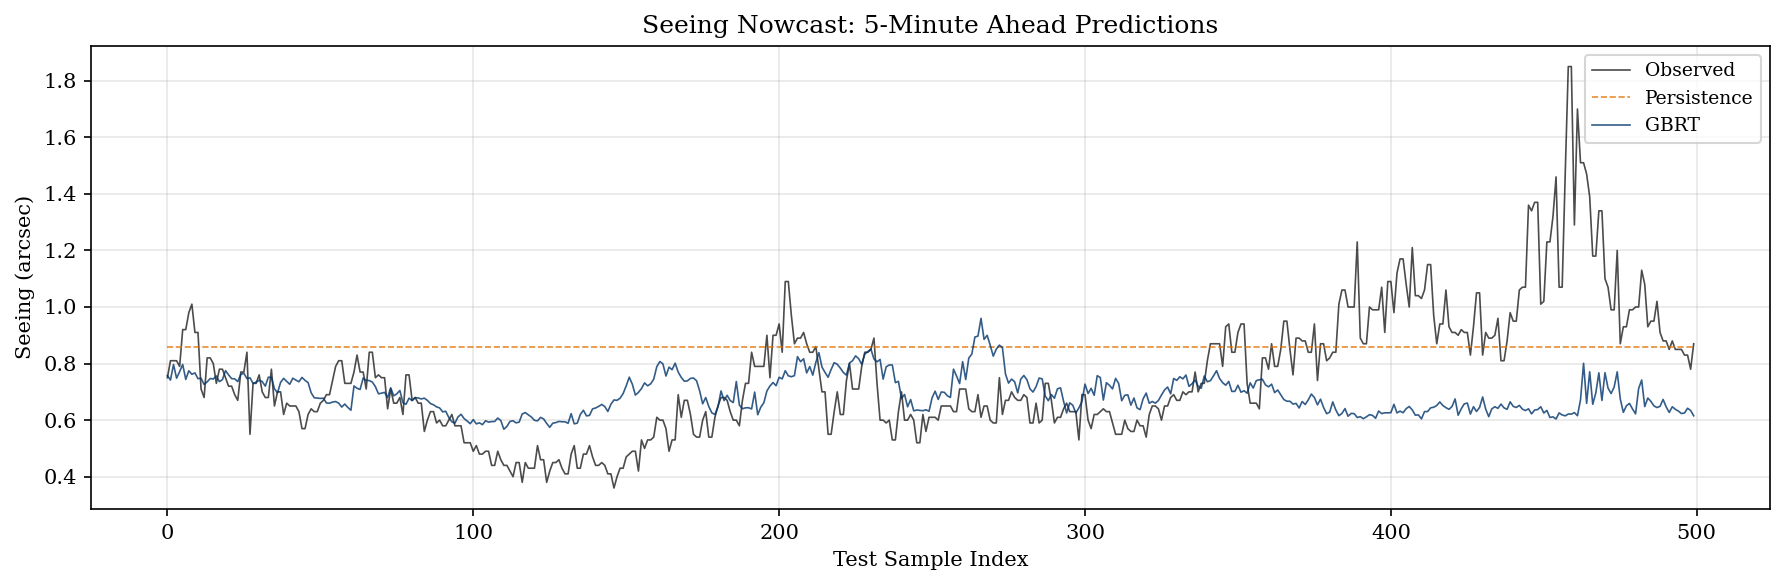

In [7]:
# Visual comparison on a 500-sample test window
_, y_pred_persist = task.evaluate_model(persist.predict, return_predictions=True)
_, y_pred_gbrt = task.evaluate_model(gbrt.predict, return_predictions=True)

X_test, y_test = task.get_test_data(data_type="pd")
_, y_test_fw = task.prepare_forecasting_data(X_test, y_test)

n_plot = min(500, len(y_test_fw))
idx = range(n_plot)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(idx, y_test_fw.values[:n_plot], 'k-', lw=0.8, alpha=0.7, label='Observed')
ax.plot(idx, y_pred_persist[:n_plot], '--', color='#E07000', lw=0.8, alpha=0.8, label='Persistence')
ax.plot(idx, y_pred_gbrt[:n_plot], '-', color='#00356B', lw=0.8, alpha=0.8, label='GBRT')

ax.set_xlabel('Test Sample Index')
ax.set_ylabel('Seeing (arcsec)')
ax.set_title('Seeing Nowcast: 5-Minute Ahead Predictions')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Model | Approach | Training Time | Hardware |
|-------|----------|:------------:|:--------:|
| **Persistence** | Last observed value | ~0 s | Any |
| **GBRT** | LightGBM (200 trees, depth 6) | ~30 s | 2-core, 8 GB |

Both models serve as baselines for the `seeing_nowcast` task. The GBRT model demonstrates that even a modest tree ensemble can improve on persistence by leveraging the thermodynamic context (LHATPRO temperature profiles, surface meteorology) available in the observation window.

**Next steps**:
- Apply the same pattern to the grand-challenge task (`cn2_profile_forecast`) for 7-layer vector forecasting
- Explore temporal feature engineering (hour-of-night, solar elevation)
- Evaluate recurrent architectures (LSTM, Transformer) for longer-horizon prediction